<a href="https://colab.research.google.com/github/cristianofanchin/puc-rio/blob/main/MVP_Sprint_MLA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Brasao Puc-Rio](https://www.puc-rio.br/imagens/bras_83x140_reduzido.png)

## Puc-Rio
## Pós-Graduação em Ciência de Dados e Analytics
Aluno: Cristiano Weiber Fanchin


## Sprint 2 - Machine Learning & Analytics - MVP


---

Na sprint anterior do curso, foram realizadas as etapas de análise exploratória e pré-processamento de dados contidos em um dataset com mais de 128 mil registros de características de indivíduos e de seu perfil psicológico, com base no Indicador de Tipo Myers-Briggs (MBTI), formulado por Katharine Cook Briggs e Isabel Briggs Myer.

Para o MVP desta presente sprint - Machine Learning & Analytics - iremos trabalhar em modelos de machine learning para um problema de classificação com base nesse dataset. Estarão contempladas as etapas de carga dos dados, separação entre treino e teste, pré-processamento, treinamento de modelos de ML, ajuste de hipreparâmetros, análise dos resultados e comparação dos modelos.

O pré-processamento de dados nesse MVP vai ser diferente daquele efetuado na sprint de Análise de Dados e Boas Práticas, dado que o conhecimento adquirido na sprint de Machine Learning & Analytics me permitiu identificar algumas melhores transformações de variáveis numéricas e categoóricas.


![texto alt](https://github.com/cristianofanchin/puc-rio/blob/main/img2.png?raw=true)


## Conhecendo o dataset e o problema de classificação

O  Indicador de Tipo Myers-Briggs (MBTI) se baseia nas teorias de tipos psicológicos formuladas pelo psiquiatra Carl Jung, oferecendo uma abordagem detalhada para a compreensão das diferenças individuais na personalidade.

O processo envolve responder a uma série de perguntas que avaliam as preferências do indivíduo em **quatro dimensões** principais:

*   Extroversão (E) vs. Introversão (I)
*   Sensação (S) vs. Intuição (N)
*   Pensamento (T) vs. Sentimento (F)
*   Julgamento (J) vs. Percepção (P)

Cada uma dessas dimensões tem duas categorias opostas, e as respostas ao questionário determinam em qual categoria de cada dimensão a pessoa se encaixa. Combinando essas preferências, o MBTI classifica os indivíduos em um dos 16 tipos de personalidade possíveis, cada um representado por um código de quatro letras, organizados em 4 grupos: Racionalizadoras, Realizadoras, Idealistas e Exploradoras.

**Racionalizadoras:**
*Pessoas que se destacam pela abordagem lógica e analítica para resolver problemas. São estrategistas e pensadores independentes, focados em otimização e melhorias.*
1. Arquiteto (INTJ)
2. Lógico (INTP)
3. Inventor (ENTP)
4. Comandante (ENTJ)

**Realizadoras:**
*Pessoas organizadas e responsáveis, com uma forte orientação para a estrutura e o suporte aos outros. Valorizam a eficiência e o cumprimento de responsabilidades.*
5. Administrador (ISTJ)
6. Supervisor (ESTJ)
7. Provedor (ESFJ)
8. Defensor (ISFJ)

**Idealistas:**
*Pessoas guiadas por valores profundos e ideais pessoais. Buscam compreender e apoiar os outros, motivadas por um desejo de fazer a diferença e contribuir para causas que acreditam ser justas.*
9. Advogado (INFJ)
10. Mediador (INFP)
11. Protagonista (ENFP)
12. Mentor (ENFJ)

**Exploradoras:**
*Pessoas práticas e enérgicas, sempre em busca de novas experiências e aventuras. São adaptáveis e espontâneas, com uma abordagem direta para viver e explorar o mundo ao seu redor.*
13. Virtuoso (ISTP)
14. Aventureiro (ISFP)
15. Empreendedor (ESTP)
16. Animador (ESFP)

Fonte: https://br.indeed.com/conselho-de-carreira/desenvolvimento-de-carreira/tipos-de-personalidade

Obs: uma descrição de cada um dos 16 perfis pode ser consultada na URL acima.

---








**Análise inicial do dataset**

O dataset em questão, hospedado no Kaggle [neste link](https://www.kaggle.com/datasets/stealthtechnologies/predict-people-personality-types/data), contém atributos representando as quatro dimensões acima citadas pertencentes ao modelo de Myers-Briggs, o perfil de personalidade MBTI resultante, bem como fatores adicionais de cada indivíduo da amostra: idade, gênero, grau de educação e área de interesse principal.

Esse dataset é adequado à construção e estudo de modelos de Machine Learning do tipo *Classificação* , tendo com target o perfil profissional do indivíduo, dentre um universo de 16 classes possíveis.

A análise exploratória completa do dataset pode ser verificada no [MVP construído para a sprint anterior.](https://github.com/cristianofanchin/puc-rio/blob/main/MVP_Sprint_ADBP.ipynb)

Importação das bibliotecas necessárias:

In [1]:
# importação dos módulos
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

import warnings
warnings.filterwarnings("ignore")

Leitura dos dados para um dataframe do Pandas:

In [2]:
# carga do dataset armazenado no GitHub
url = 'https://raw.githubusercontent.com/cristianofanchin/puc-rio/refs/heads/main/people_personality_types.csv'
df = pd.read_csv(url)

Análise das informações principais do dataset:

In [3]:
# dimensões do dataset
df.shape

(128061, 9)

In [4]:
# informações básicas do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128061 entries, 0 to 128060
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Age                 128061 non-null  float64
 1   Gender              128061 non-null  object 
 2   Education           128061 non-null  int64  
 3   Introversion Score  128061 non-null  float64
 4   Sensing Score       128061 non-null  float64
 5   Thinking Score      128061 non-null  float64
 6   Judging Score       128061 non-null  float64
 7   Interest            128061 non-null  object 
 8   Personality         128061 non-null  object 
dtypes: float64(5), int64(1), object(3)
memory usage: 8.8+ MB


In [5]:
# exibição das primeiras linhas
df.head()

,Age,Gender,Education,Introversion Score,Sensing Score,Thinking Score,Judging Score,Interest,Personality
0,19.0,Male,0,9.47080,7.141434,6.03696,4.360278,Unknown,ENFP
1,27.0,Female,0,5.85392,6.160195,0.80552,4.221421,Sports,ESFP
2,21.0,Female,0,7.08615,3.388433,2.66188,5.127320,Unknown,ENFP
3,28.0,Male,0,2.01892,4.823624,7.30625,5.986550,Others,INTP
4,36.0,Female,1,9.91703,4.755080,5.31469,4.677213,Technology,ENFP


Observando o retorno dos métodos `df.info()` e `df.head()`, identificamos as variáveis numéricas e categóricas do dataset. Também percebemos ausência de "nulos".

Segundo a documentação presente no Kaggle, as variáveis numéricas *Score* da lista abaixo são números reais que variam entre 0 e 10 e representam a tendência do indivíduo em cada uma das dimensões avaliadas:



Variável Score              | Valor alto indica: | Valor baixo indica:
----------------------------|--------------------|------------------
**Introversion Score**      |   extroversão      |  introversão
**Sensing Score**           |   sensação         |  intuição
**Thinking Score**          |   pensamento       |  sentimento
**Judging Score**           |   julgamento       |  percepção


Outra variável numérica é *Age* (idade do indivíduo).

As demais variáveis do dataset são categóricas:



*   *Gender*
        variável binária em forma de string, para representar o gênero masculino ou feminino.
*   *Education*
        variável binária, sendo 1 para indicar nível superior completo ou maior, ou 0 para os níveis educacionais inferiores.
*   *Interest*
        string representando a área de interesse principal, possivelmente apontada pelo indivíduo na resposta ao questionário.
*   *Personality*
        string de 4 caracteres representando um dos 16 tipos de personalidade do indivíduo segundo o MBTI.



In [6]:
# Domínio das variáveis categóricas do tipo string
for col in df.columns[df.dtypes=='object']:
  print(f"{col}: {df[col].unique()}\n")

Gender: ['Male' 'Female']

Interest: ['Unknown' 'Sports' 'Others' 'Technology' 'Arts']

Personality: ['ENFP' 'ESFP' 'INTP' 'INFP' 'ENFJ' 'ENTP' 'ESTP' 'ISTP' 'INTJ' 'INFJ'
 'ISFP' 'ENTJ' 'ESFJ' 'ISFJ' 'ISTJ' 'ESTJ']



Como a variável categórica *Education* já veio codificada com 0 ou 1, em tipo *int64*, a transformação pevista para ela apenas passará seu tipo de *int64* para *float*.

## Pré-processamento

Nesta seção, criaremos a sequência de transformações necessárias às variáveis.

Inicialmente, os dados serão separados em conjuntos de treino e de teste.


In [7]:
# Separação das variáveis  - features (X) e target (y)
X = df.drop('Personality', axis=1)
y = df['Personality']

# Divisão entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Faremos a transformação da variável target pelo método de Label Encoding. Esse método foi escolhido pois os modelos de machine learning que serão abordados nesse MVP não requerem explicitamente o One Hot Encoding para o target (como seria o caso das redes neurais, por exemplo) e o uso desse último método traria complexidade desnecessária.



In [8]:
# Transformação Label Encoding da variável target
le=LabelEncoder()
y_train = pd.Series(le.fit_transform(y_train), index=y_train.index, name='Personality')
y_test = pd.Series(le.transform(y_test), index=y_test.index, name='Personality')

print('y_train após Label Encoding\n')
print(y_train.info())
print('\n\nt_test após Label Encoding\n')
print(y_test.info())

y_train após Label Encoding

<class 'pandas.core.series.Series'>
Index: 89642 entries, 127876 to 121958
Series name: Personality
Non-Null Count  Dtype
--------------  -----
89642 non-null  int64
dtypes: int64(1)
memory usage: 1.4 MB
None


t_test após Label Encoding

<class 'pandas.core.series.Series'>
Index: 38419 entries, 33507 to 34436
Series name: Personality
Non-Null Count  Dtype
--------------  -----
38419 non-null  int64
dtypes: int64(1)
memory usage: 600.3 KB
None


Como próxima etapa, faremos:

*   a padronização das features numéricas usando StandardScaler;
*   a transformação das features categóricas pelo método de One Hot Encoding.



Usaremos para tal a classe *ColumnTransformer*, que nos permite aplicar diferentes transformações a diferentes colunas de um conjunto de dados.


In [9]:
# Definir as colunas
colunas_numericas = ['Age', 'Introversion Score', 'Sensing Score', 'Thinking Score', 'Judging Score']
colunas_categoricas = ['Gender', 'Interest']

# Criar os transformadores
transformadores = [
    ('padr', StandardScaler(), colunas_numericas),
    ('onehot', OneHotEncoder(), colunas_categoricas)]

# Criar o ColumnTransformer
preprocessor = ColumnTransformer(transformers=transformadores, remainder='passthrough')


In [10]:
# Aplicar transformações
X_train_transformed_array = preprocessor.fit_transform(X_train)
X_test_transformed_array = preprocessor.transform(X_test)

# Reconstruir os DataFrames
X_train_transformed_df = pd.DataFrame(X_train_transformed_array,
    columns=(preprocessor.get_feature_names_out()), index=X_train.index)
X_test_transformed_df = pd.DataFrame(X_test_transformed_array,
    columns=(preprocessor.get_feature_names_out()), index=X_test.index)

Verificando o resultado desse processo:

In [11]:
X_train_transformed_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89642 entries, 127876 to 121958
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   padr__Age                    89642 non-null  float64
 1   padr__Introversion Score     89642 non-null  float64
 2   padr__Sensing Score          89642 non-null  float64
 3   padr__Thinking Score         89642 non-null  float64
 4   padr__Judging Score          89642 non-null  float64
 5   onehot__Gender_Female        89642 non-null  float64
 6   onehot__Gender_Male          89642 non-null  float64
 7   onehot__Interest_Arts        89642 non-null  float64
 8   onehot__Interest_Others      89642 non-null  float64
 9   onehot__Interest_Sports      89642 non-null  float64
 10  onehot__Interest_Technology  89642 non-null  float64
 11  onehot__Interest_Unknown     89642 non-null  float64
 12  remainder__Education         89642 non-null  float64
dtypes: float64(13)


In [12]:
X_train_transformed_df.head(10)

,padr__Age,padr__Introversion Score,padr__Sensing Score,padr__Thinking Score,padr__Judging Score,onehot__Gender_Female,onehot__Gender_Male,onehot__Interest_Arts,onehot__Interest_Others,onehot__Interest_Sports,onehot__Interest_Technology,onehot__Interest_Unknown,remainder__Education
127876,-0.477456,-1.383393,0.188454,-0.396080,-0.139281,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
39746,-0.681354,1.379014,0.858252,0.107300,0.263541,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
29021,-0.273557,0.402887,0.529561,-0.547904,-0.306027,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
90128,1.561527,-1.619144,1.593502,-1.721230,0.158452,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
120934,0.949832,0.619817,-1.099434,-1.178831,-1.284897,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22770,-0.681354,-0.839099,-0.042933,-1.449261,0.015220,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
31532,-0.069659,-1.523596,0.194035,1.640863,1.306998,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
51758,-1.089150,-0.339656,-0.607779,-0.418701,-1.040958,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
124928,-0.681354,-1.609534,-1.267422,-1.489323,0.170979,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
59396,1.765425,1.599903,0.150710,1.536000,1.467777,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


In [13]:
X_test_transformed_df.head(10)

,padr__Age,padr__Introversion Score,padr__Sensing Score,padr__Thinking Score,padr__Judging Score,onehot__Gender_Female,onehot__Gender_Male,onehot__Interest_Arts,onehot__Interest_Others,onehot__Interest_Sports,onehot__Interest_Technology,onehot__Interest_Unknown,remainder__Education
33507,-0.681354,1.299697,-0.300849,0.416461,-2.467602,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
16990,-0.069659,0.145376,0.996357,-1.382251,-0.075551,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
91298,-0.477456,0.816658,1.362365,-0.570355,-1.658059,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
66353,-1.293048,1.144958,-0.147713,0.301853,-1.627364,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2271,-1.293048,1.716868,0.129396,0.759336,-0.209312,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
16133,-1.496947,-1.329303,-0.736909,0.193270,-1.107768,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
35054,1.969323,1.556833,-0.373657,1.463877,-1.382205,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
89440,-1.089150,-1.504224,-0.415951,-0.552359,0.454070,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
59907,0.542036,1.615888,1.009827,0.633984,0.562840,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
7713,0.338137,-1.658005,-0.093409,1.372607,-1.490766,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


Verificamos agora o gráfico de densidade kernel (KDE - Kernel Density Estimation) das features dos dataframes **X_train_transformed_df** e **X_test_transformed_dft** por meio de Density Plots do módulo Matplolib:

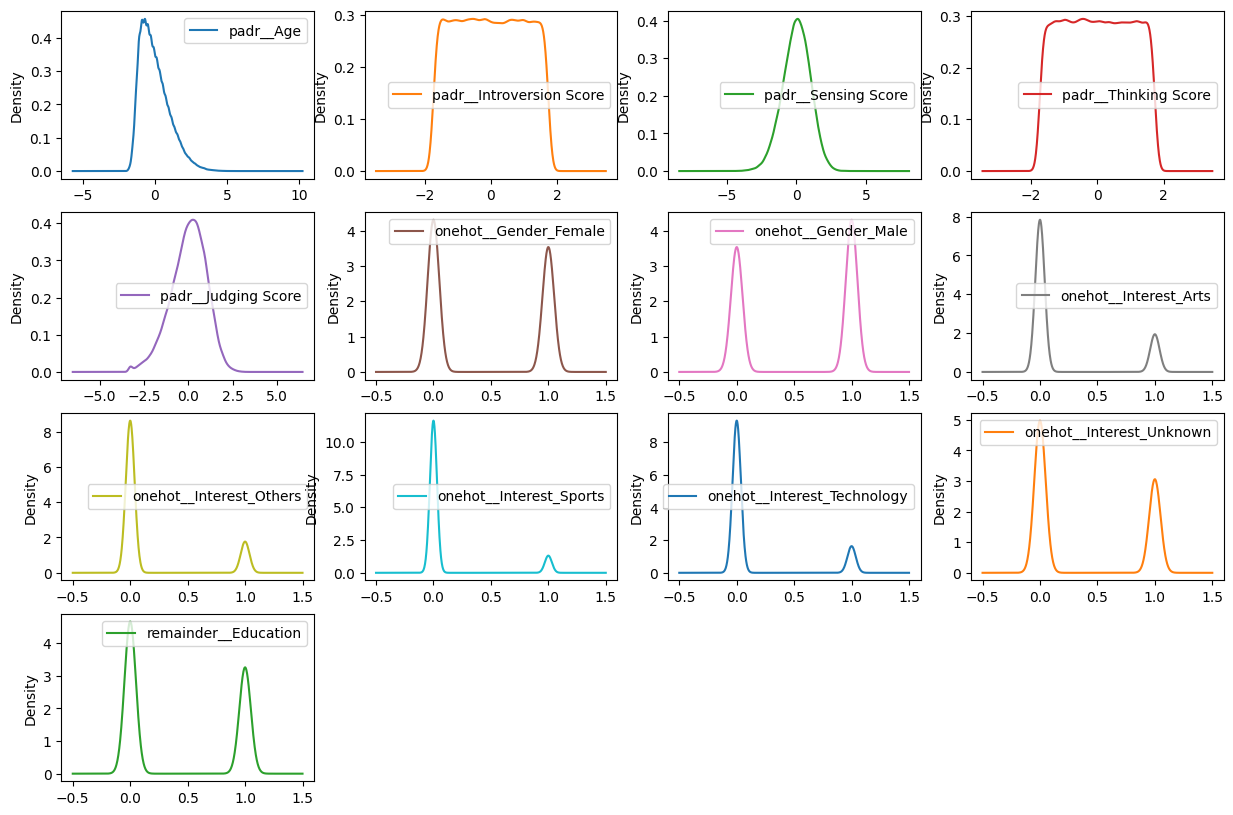

In [14]:
# Density Plot de X_train
X_train_transformed_df.plot(kind = 'density', subplots = True, layout = (4,4), sharex = False, figsize = (15,10))
plt.show()

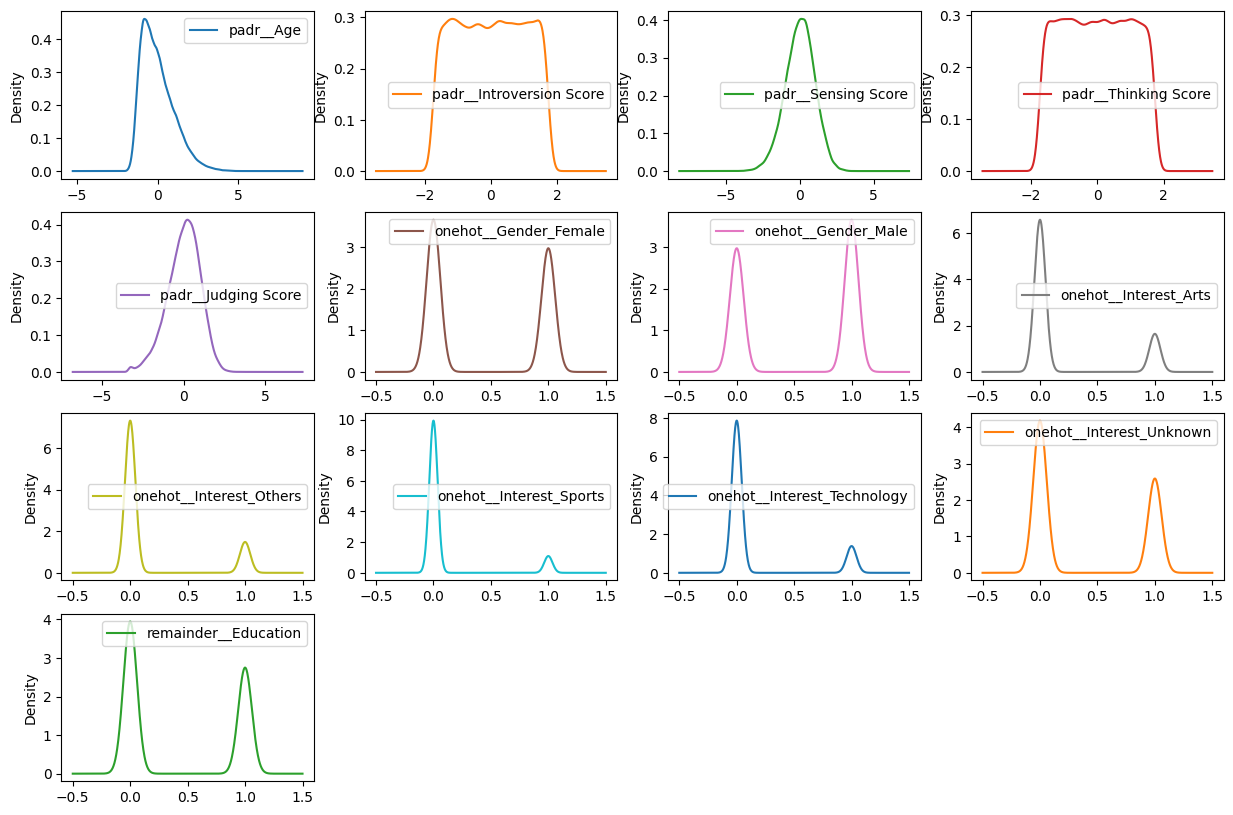

In [15]:
# Density Plot de X_test
X_test_transformed_df.plot(kind = 'density', subplots = True, layout = (4,4), sharex = False, figsize = (15,10))
plt.show()

Podemos observar que as distribuições de **X_train_transformed_df** e **X_test_transformed_dft** são similares, para cada uma das features.

## Treinamento de modelos de machine learning

Serão criados *pipelines* para o sequenciamento de ações de pré-processamento e treinamento de diversos modelos de classificação, a fim de encontrar aqueles de melhor resultado. O uso da classe *ColumnTransformer* na etapa anterior viabiliza essa abordagem.
Será adotada também a técnica de validação cruzada com 5 folds, sobre a base de treino do dataset.

In [16]:
# imports específicos
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Seed global
np.random.seed(42)

num_trees = 100
max_features = 3

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # validação cruzada com estratificação
scoring = 'accuracy'

# Modelos de Machine Learning a serem avaliados
reg_log = ('LR', LogisticRegression(max_iter=200))
knn = ('KNN', KNeighborsClassifier())
cart = ('CART', DecisionTreeClassifier())
naive_bayes = ('NB', GaussianNB())
svm = ('SVM', SVC())
random_forest = ('RF', RandomForestClassifier(n_estimators=num_trees, max_features=max_features))
extra_trees = ('ET', ExtraTreesClassifier(n_estimators=num_trees, max_features=max_features))
adaboost = ('Ada', AdaBoostClassifier(n_estimators=num_trees))

# Tupla do pré-processamento
prep = ('preprocessamento', preprocessor)

In [17]:
# Criação dos diversos pipelines para execução dos treinos
pipelines = []
pipelines.append(('LR', Pipeline(steps=[prep, reg_log])))
pipelines.append(('KNN', Pipeline(steps=[prep, knn])))
pipelines.append(('CART', Pipeline(steps=[prep, cart])))
pipelines.append(('NB', Pipeline(steps=[prep, naive_bayes])))
pipelines.append(('SVM', Pipeline(steps=[prep, svm])))
pipelines.append(('RF', Pipeline(steps=[prep, random_forest])))
pipelines.append(('ET', Pipeline(steps=[prep, extra_trees])))
pipelines.append(('Ada', Pipeline(steps=[prep, adaboost])))


![texto alt](https://github.com/cristianofanchin/puc-rio/blob/main/img_atencao.png?raw=true) **Atenção: o bloco abaixo leva mais de 10 minutos para executar.**


In [18]:
# Executando os pipelines
results = []
names = []

print('Resultados de acurácia da validação cruzada:\n')
print('Modelo\tmédia\tdesvio padrão\ttempo gasto')

for name, model in pipelines:
    tic = time.time()
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    toc = time.time()
    results.append(cv_results)
    names.append(name)
    print(f'{name}\t{cv_results.mean():.3f}\t{cv_results.std():.3f}\t\t{(toc-tic)/60:.2f} min')


Resultados de acurácia da validação cruzada:

Modelo	média	desvio padrão	tempo gasto
LR	0.859	0.002		0.57 min
KNN	0.800	0.004		0.43 min
CART	0.873	0.003		0.07 min
NB	0.639	0.025		0.01 min
SVM	0.884	0.002		8.63 min
RF	0.902	0.001		1.45 min
ET	0.856	0.002		0.99 min
Ada	0.364	0.020		1.19 min


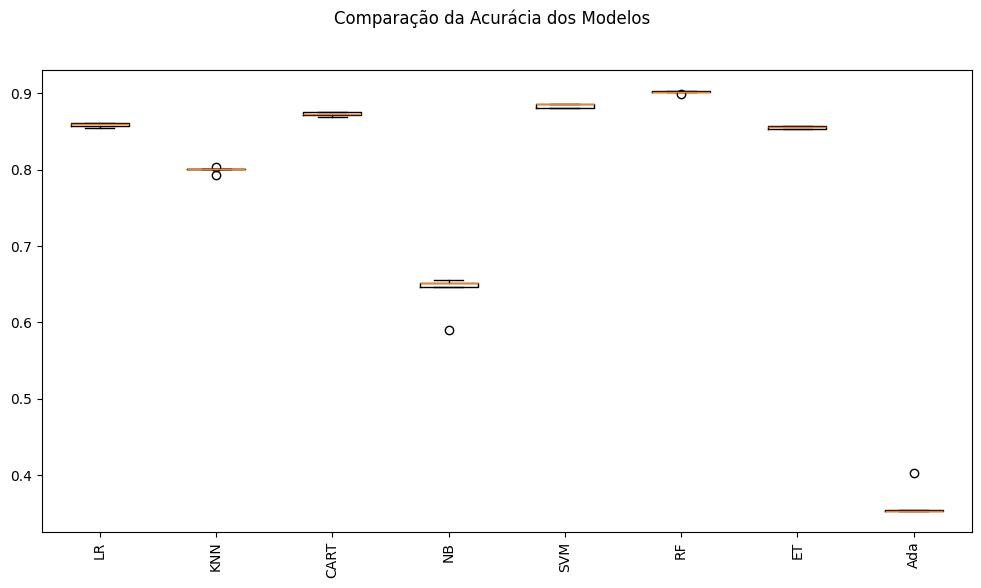

In [19]:
# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(12,6))
fig.suptitle('Comparação da Acurácia dos Modelos')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names, rotation=90)
plt.show()

## Ajuste dos hiperparâmetros

Tendo encontrado melhor acurácia com o modelo *Random Forest*, iremos agora usar a técnica *GridSearchCV* para encontrar os melhores hiperparâmetros para esse modelo.

![texto alt](https://github.com/cristianofanchin/puc-rio/blob/main/img_atencao.png?raw=true) **Atenção: o bloco abaixo leva mais de 5 minutos para executar.**




In [20]:
# Definir a grade de hiperparâmetros
param_grid = {
    'RF__n_estimators': [50, 100, 150], # Número de árvores na floresta
    'RF__max_depth': [10, 20],          # Profundidade máxima da árvore
    'RF__max_features': [3]             # Máximo de features consideradas em cada divisão
}

# Execução do GridSearchCV

grid = GridSearchCV(
    estimator=Pipeline(steps=[prep, ('RF', RandomForestClassifier(random_state=42))]),
    param_grid=param_grid,
    scoring=scoring,
    cv=5,                # Validação cruzada com 5 divisões
    verbose=1,           # Mostrar progresso
    n_jobs=-1            # Usar todos os núcleos disponíveis
)

tic = time.time()
grid.fit(X_train, y_train)
toc = time.time()

print(f'\nMelhor resultado de acurária: {grid.best_score_:.3f} com os parâmetros {grid.best_params_}\n')
print(f'Tempo de execução: {(toc-tic)/60:.2f} min')

Fitting 5 folds for each of 6 candidates, totalling 30 fits

Melhor resultado de acurária: 0.903 com os parâmetros {'RF__max_depth': 20, 'RF__max_features': 3, 'RF__n_estimators': 150}

Tempo de execução: 6.93 min


## Finalização do modelo escolhido

In [21]:
# Avaliação do modelo com o conjunto de testes

best_rf = grid.best_estimator_
best_params = grid.best_params_

# Construir o pipeline final
pipeline_final = Pipeline(steps=[
    ('preprocessamento', preprocessor),
    ('modelo', RandomForestClassifier(max_depth=best_params['RF__max_depth'],
                                      max_features=best_params['RF__max_features'],
                                      n_estimators=best_params['RF__n_estimators'],
                                      random_state=42))
])

# Treinar o modelo
pipeline_final.fit(X_train, y_train)

# Fazer previsão para o conjunto de teste
y_pred = pipeline_final.predict(X_test)

# Avaliar a acurácia
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.90705119862568

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.92      0.92      1180
           1       0.93      0.93      0.93     10341
           2       0.92      0.92      0.92       820
           3       0.92      0.92      0.92      7504
           4       0.80      0.85      0.83       158
           5       0.85      0.85      0.85      1420
           6       0.87      0.83      0.85       115
           7       0.86      0.83      0.85       976
           8       0.91      0.90      0.91       924
           9       0.90      0.91      0.91      7389
          10       0.91      0.89      0.90       567
          11       0.89      0.90      0.90      5138
          12       0.82      0.71      0.76       115
          13       0.83      0.79      0.81      1000
          14       0.85      0.79      0.82        71
          15       0.84      0.81      0.83       701

    accuracy                

A acurácia encontrada sobre o conjunto de testes ficou muito próxima àquela encontrada no processo *GridSearchCV*, o que nos indica uma boa qualidade de aprendizado, com baixa probabilidade de ter ocorrido o *overfitting*.

Vamos vizualizar a matriz de confusão resultante:

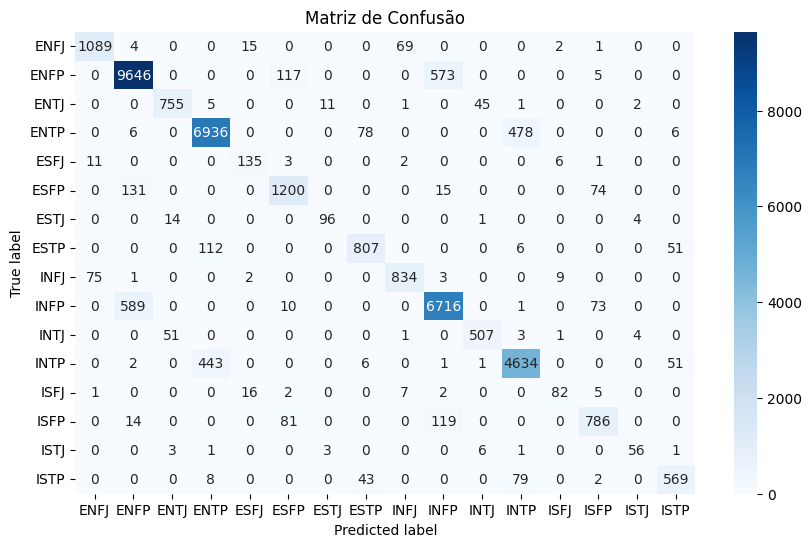

In [22]:
# Matriz de Confusão
plt.figure(figsize=(10,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [23]:
# Treinamento do modelo com todo o dataset

# inicialmente promover a transformação Label Encoding da variável y
le_final=LabelEncoder()
y = pd.Series(le_final.fit_transform(y), index=y.index, name='Personality')

# Treinamento
pipeline_final.fit(X, y)

Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('padr', StandardScaler(),
                                                  ['Age', 'Introversion Score',
                                                   'Sensing Score',
                                                   'Thinking Score',
                                                   'Judging Score']),
                                                 ('onehot', OneHotEncoder(),
                                                  ['Gender', 'Interest'])])),
                ('modelo',
                 RandomForestClassifier(max_depth=20, max_features=3,
                                        n_estimators=150, random_state=42))])

In [24]:
# Salvamento do projeto para uso futuro

import joblib

# modelo treinado
joblib.dump(pipeline_final, 'modelo_final.joblib')

# codificador do target
joblib.dump(le_final, 'le_final.joblib')



['le_final.joblib']

Como os arquivos são salvos localmente no ambiente temporário de execução do Google Colab, recomenda-se fazer o download dos mesmos, ou alterar o código para que o arquivo seja salvo permanentemente no seu Google Drive, conforme explicado nesse link: https://colab.research.google.com/notebooks/io.ipynb#scrollTo=u22w3BFiOveA.

In [25]:
# Em futuras utilizações, usar o código abaixo, retirando as marcas de comentário

#pipeline_carregado = joblib.load('modelo_final.joblib')                          # Carregar o pipeline
#le_carregado = joblib.load('le_final.joblib')                                    # Carregar o codificador do target
#predicoes = le_carregado.inverse_transform(pipeline_carregado.predict(X_novo))   # Fazer previsões com o pipeline carregado

## Conclusão

As técnicas aplicadas no MVP permitiram aprimorar os conhecimentos sobre os modelos clássicos de machine learning.
Para o problema em questão, o modelo de melhor acurácia foi o de Florestas Aleatórias (*Random Forest*), tendo sua acurácia acima de 90% nas etapas de validação cruzada, bem como na validação com o conjunto de teste.

O uso das técnicas avançadas como *Pipelines* e *GridSearch* possibilitam ao cientista de dados executar sequências de treinamentos e de avaliação de modelos, o que traz eficiência ao processo de modelagem  e inferência.

No decorrer do desenvolvimento do MVP, algumas reduções de escopo e simplificações foram necessárias, pois caso contrário seriam gastas algumas horas para rodar o notebook. Como por exemplo, deixamos de avaliar o ensemble *Gradient Boosting* e também reduzimos as quantidades de hiperparâmetros para o *GridSearch*. Tais simplificações não comprometeram o resultado final obtido.

Como próximos trabalhos, sugere-se avaliar o desempenho de redes neurais para o problema de classificação desse MVP.


---

